# Exploratory Data Analysis: Support Tickets

This notebook explores the Support Ticket Dataset to justify modeling choices, analyze data distributions, handle missing values, and extract common n-grams.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import itertools
from sklearn.feature_extraction.text import CountVectorizer

%matplotlib inline
sns.set_theme(style="whitegrid")

# Load data
df = pd.read_csv('../tickets.csv')
display(df.head())

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


## 1. Missing Values Analysis
Checking for null values in critical columns.

Missing values per column:
Resolution                      5700
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64


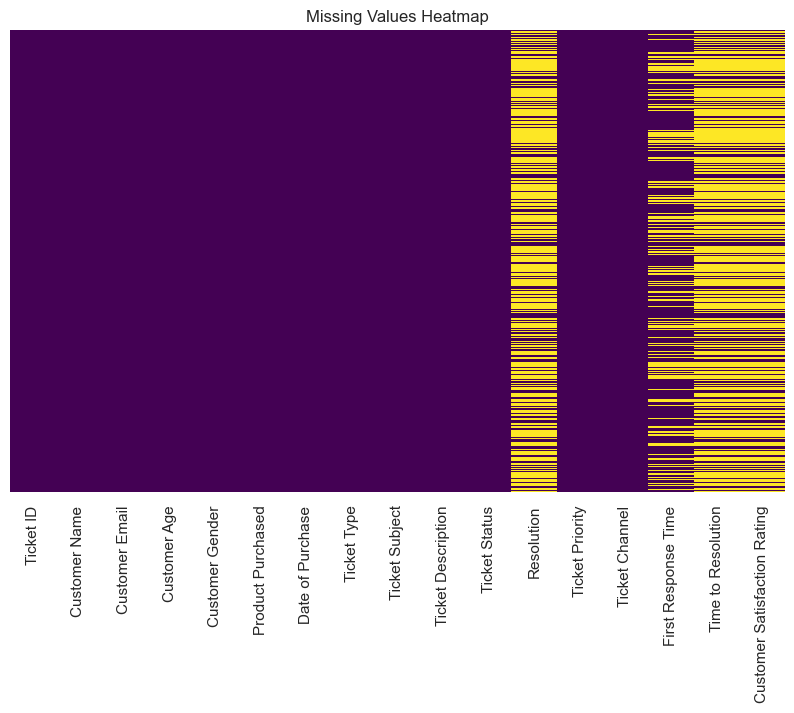

In [2]:
missing_vals = df.isnull().sum()
print("Missing values per column:")
print(missing_vals[missing_vals > 0])

plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

## 2. Class Distribution
Checking if our categories are imbalanced, which affects whether we use simple accuracy or weighted F1 macro scores.

C:\Users\Calla\AppData\Local\Temp\ipykernel_87876\3490672662.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=cat_col, order=order, palette="viridis")


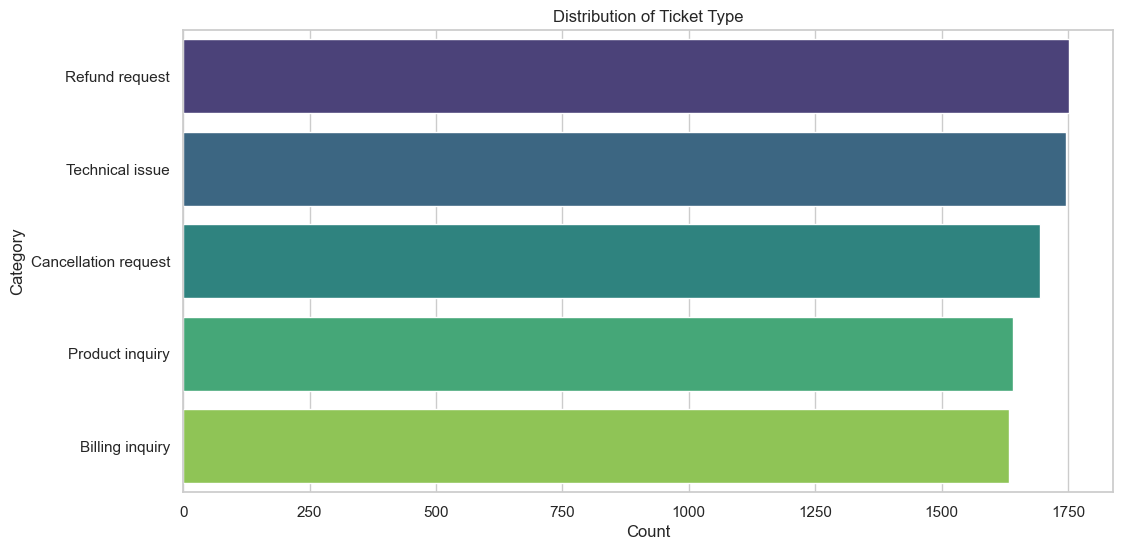

Class representation:
 Ticket Type
Refund request          0.206872
Technical issue         0.206282
Cancellation request    0.200142
Product inquiry         0.193765
Billing inquiry         0.192939
Name: proportion, dtype: float64


In [3]:
cat_col = 'Ticket Type' if 'Ticket Type' in df.columns else 'Category'
if cat_col not in df.columns and 'category' in df.columns:
    cat_col = 'category'

if cat_col in df.columns:
    plt.figure(figsize=(12, 6))
    order = df[cat_col].value_counts().index
    sns.countplot(data=df, y=cat_col, order=order, palette="viridis")
    plt.title(f'Distribution of {cat_col}')
    plt.xlabel('Count')
    plt.ylabel('Category')
    plt.show()
    
    print("Class representation:\n", df[cat_col].value_counts(normalize=True))

## 3. Text Length Analysis
Analyzing the character and word counts of Ticket Subjects and Descriptions.

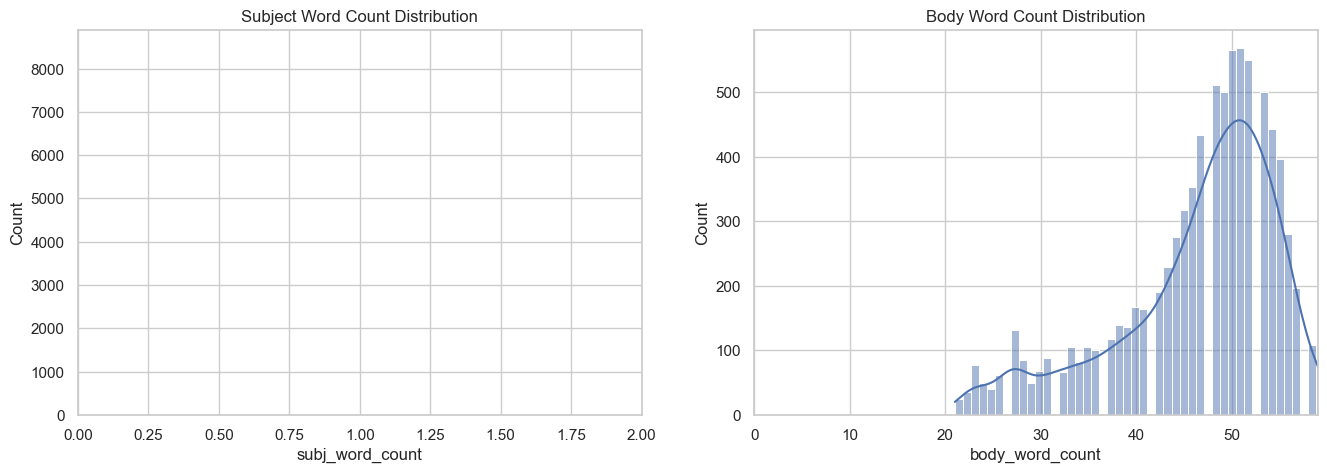

In [4]:
subj_col = 'Ticket Subject' if 'Ticket Subject' in df.columns else 'subject'
body_col = 'Ticket Description' if 'Ticket Description' in df.columns else 'body'

# Create word count features
if subj_col in df.columns:
    df['subj_word_count'] = df[subj_col].astype(str).apply(lambda x: len(x.split()))
if body_col in df.columns:
    df['body_word_count'] = df[body_col].astype(str).apply(lambda x: len(x.split()))

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
if subj_col in df.columns:
    sns.histplot(df['subj_word_count'], bins=50, ax=ax[0], kde=True)
    ax[0].set_title('Subject Word Count Distribution')
    ax[0].set_xlim(0, df['subj_word_count'].quantile(0.99))

if body_col in df.columns:
    sns.histplot(df['body_word_count'], bins=50, ax=ax[1], kde=True)
    ax[1].set_title('Body Word Count Distribution')
    ax[1].set_xlim(0, df['body_word_count'].quantile(0.99))

plt.show()

## 4. Top N-Grams Extraction
Exploring common unigrams and bigrams to inform our text vectorization strategies.

C:\Users\Calla\AppData\Local\Temp\ipykernel_87876\721925961.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='Unigram', data=udf, ax=ax[0], palette="Blues_r")
C:\Users\Calla\AppData\Local\Temp\ipykernel_87876\721925961.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='Bigram', data=bdf, ax=ax[1], palette="Greens_r")


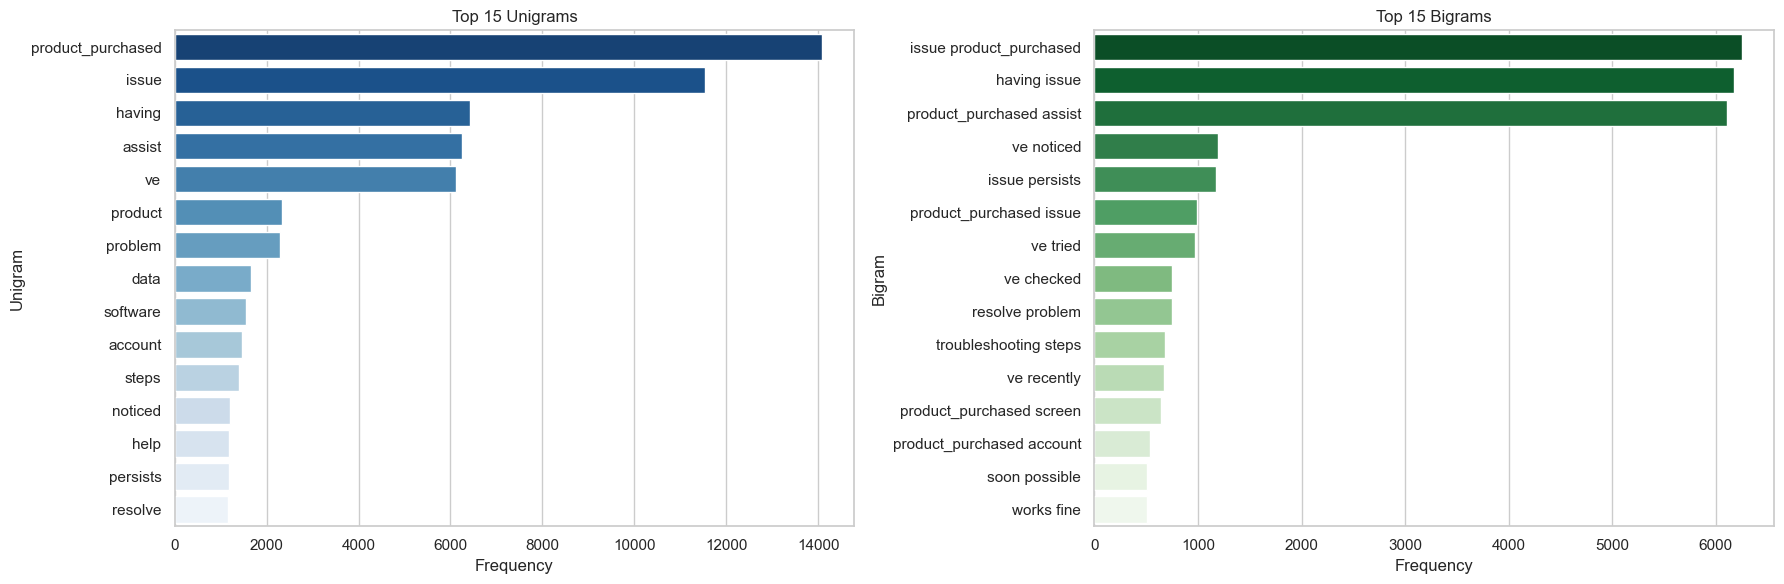

In [5]:
def get_top_ngrams(corpus, n=None, ngram_range=(1,1)):
    vec = CountVectorizer(ngram_range=ngram_range, stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

if body_col in df.columns:
    text_sample = df[body_col].dropna().astype(str).sample(min(10000, len(df)), random_state=42)
    
    top_unigrams = get_top_ngrams(text_sample, n=15, ngram_range=(1,1))
    top_bigrams = get_top_ngrams(text_sample, n=15, ngram_range=(2,2))
    
    fig, ax = plt.subplots(1, 2, figsize=(18, 6))
    
    # Unigrams
    udf = pd.DataFrame(top_unigrams, columns=['Unigram', 'Frequency'])
    sns.barplot(x='Frequency', y='Unigram', data=udf, ax=ax[0], palette="Blues_r")
    ax[0].set_title('Top 15 Unigrams')
    
    # Bigrams
    bdf = pd.DataFrame(top_bigrams, columns=['Bigram', 'Frequency'])
    sns.barplot(x='Frequency', y='Bigram', data=bdf, ax=ax[1], palette="Greens_r")
    ax[1].set_title('Top 15 Bigrams')
    
    plt.tight_layout()
    plt.show()